# ML model analyse

This notebook is used to load the model and analyse the results

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [42]:
read_image("buffer/IMAGE_X210_Y0.png").squeeze().shape
#read_image("dataset/DRR_images/C0001_X0_Y0.png").squeeze().shape

torch.Size([256, 256])

In [2]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


In [3]:
import torch.utils.data.dataloader


device = torch.device("cuda")
model = mf.Block()
data_loader_2 = mf.TestImageDataset("buffer/")
data_loader_1 = mf.CustomImageDataset(labels)
data_loader = torch.utils.data.DataLoader(data_loader_2, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


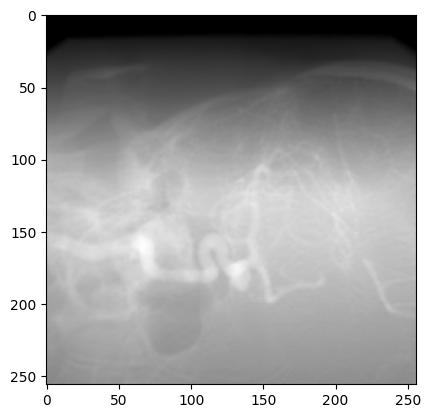

Label: IMAGE_X330_Y0.png


In [4]:
train, labels, name = next(iter(data_loader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {labels.size()}")
img = train[0].squeeze()
label = labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {name[0]}")

In [5]:
model.load_state_dict(torch.load("mymodel_classified.pth"))
model.to(device)
outputs = model(train.to(device))

In [6]:
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
outputs

tensor([[  6.9793,   7.1382,  -3.2925,   2.0926,   1.3167],
        [ -3.8673,   1.5237,   3.7290,   2.7606,   0.9003],
        [-11.7596,  11.6230,   4.5735,  11.5086,  13.6303],
        [  3.2162,  -0.7909,   5.5657,  -0.5695,  -2.5858],
        [ -0.9509,  -0.1210,   7.5000,   1.5928,  -1.6141],
        [  2.8503,  -8.7092,   7.0096,   5.8371,  -2.2686],
        [ -3.8673,   1.5237,   3.7290,   2.7606,   0.9003],
        [  2.8279,  -1.0501,   5.5109,  -0.8083,  -0.9917],
        [-16.8315,  -1.7751,   7.6084,   9.8935,   4.9824],
        [-57.7804, -30.4179,  -5.9320,  28.4741,  78.4267],
        [ 29.3471,  22.3730,  -8.9200, -14.0873, -19.0895],
        [ -4.5726,   0.8695,   4.3824,   4.5053,   0.5973],
        [ -0.9509,  -0.1210,   7.5000,   1.5928,  -1.6141],
        [-31.0762, -21.0063,   5.0611,  19.9148,  45.3195],
        [-11.4496, -21.5431,   2.1075,   1.9798,  29.9228],
        [ -7.1483,  -2.8333,   6.3688,   2.0753,   7.0548],
        [  6.3606,  -0.2946,  -5.0232,  

In [8]:
_, predicted = torch.max(outputs,1)
total = len(labels)
correct = 0

for label, prediction in zip(labels, predicted.detach().cpu()):
    if label == prediction:
        #print(label, prediction)
        correct = correct + 1

print(f'Accuracy: {(correct/total):5f}')

Accuracy: 0.140625


In [ ]:
predicted